In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

reactor_risk = pd.read_csv(
    "../outputs/results/reactor_predicted_risk_summary.csv"
)


In [9]:
reactor_risk.sort_values("avg_time_to_fault", ascending=False, inplace=True)
reactor_risk.head(6)

,reactor_id,avg_predicted_failure_risk,max_predicted_failure_risk,predicted_failure_count,actual_failure_rate,avg_efficiency_loss,avg_time_to_fault
2,A_R3,0.036498,0.582024,774,0.042052,0.631173,675.832879
0,B_R3,0.116935,0.986867,1363,0.055710,0.929208,303.606366
5,B_R2,0.022272,0.476758,10,0.013619,0.203799,230.909735
1,A_R2,0.065886,0.782827,1460,0.070139,1.052083,205.204000
4,B_R1,0.028982,0.784873,162,0.011883,0.178241,64.752140
3,A_R1,0.030990,0.146220,0,0.000000,0.000000,0.000000


B_R3 = highest average predicted risk,
A_R2 = highest actual failure rate and highest efficiency loss,
B_R1 = shortest nonzero average time to fault, and
A_R1 = no actual failures in the test period

In [10]:
#creating maintenance planning parameters
reactor_risk["maintenance_hours"] = 3 #30 min inspection + 2 hours repair + 30 min testing
reactor_risk["downtime_hours"] = 2
reactor_risk["maintenance_cost"] = 1000

#expected failure cost
reactor_risk["expected_failure_cost"] = (
    reactor_risk["avg_predicted_failure_risk"] * 10000
    + reactor_risk["avg_efficiency_loss"] * 5000
)

Because exact industrial cost data is not available, assumed maintenance and failure-cost parameters are used. The purpose is to demonstrate how predicted failure risk can be converted into a maintenance-prioritization optimization problem.

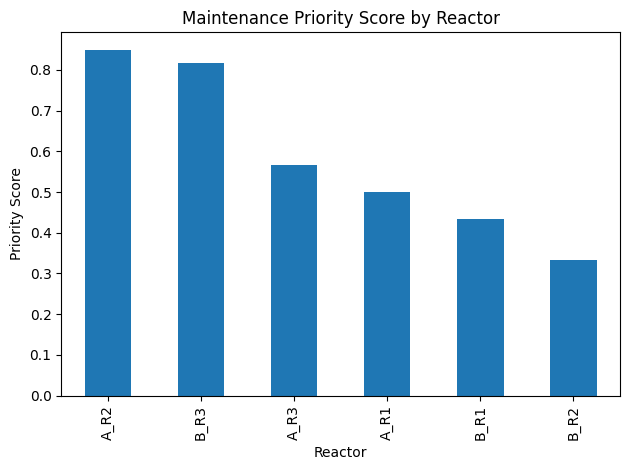

In [11]:
#ranking 
reactor_risk["urgency_score"] = 1 / (reactor_risk["avg_time_to_fault"] + 1)

reactor_risk["priority_score"] = (
    0.5 * reactor_risk["avg_predicted_failure_risk"].rank(pct=True)
    + 0.3 * reactor_risk["avg_efficiency_loss"].rank(pct=True)
    + 0.2 * reactor_risk["urgency_score"].rank(pct=True)
)

reactor_risk = reactor_risk.sort_values("priority_score", ascending=False)

reactor_risk[
    [
        "reactor_id",
        "avg_predicted_failure_risk",
        "avg_efficiency_loss",
        "avg_time_to_fault",
        "priority_score"
    ]
]

reactor_risk.plot(
    x="reactor_id",
    y="priority_score",
    kind="bar",
    legend=False
)

plt.title("Maintenance Priority Score by Reactor")
plt.xlabel("Reactor")
plt.ylabel("Priority Score")
plt.tight_layout()
plt.savefig("../outputs/figures/priority_score_by_reactor.png")
plt.show()

Decision variable:

x[i] = 1 if reactor i needs maintenance,
x[i] = 0 o.w.

Objective:

Maximize total avoided expected failure cost

Constraints:

[Total maintenance hours <= available technician hours],
[Total downtime hours <= allowed downtime], and
[Maintenance budget <= available budget]

In [12]:
available_technician_hours = 12
allowed_downtime_hours = 6
available_budget = 4000

In [13]:
from pulp import (
    LpProblem,
    LpVariable,
    LpMaximize,
    lpSum,
    LpBinary,
    LpStatus,
    value
)

In [ ]:
#creating optimization parameters
expected_failure_cost = reactor_risk.set_index("reactor_id")["expected_failure_cost"].to_dict()
maintenance_hours = reactor_risk.set_index("reactor_id")["maintenance_hours"].to_dict()
downtime_hours = reactor_risk.set_index("reactor_id")["downtime_hours"].to_dict()
maintenance_cost = reactor_risk.set_index("reactor_id")["maintenance_cost"].to_dict()

reactors = reactor_risk["reactor_id"].tolist()
#creating optimization model
model = LpProblem("Maintenance_Optimization", LpMaximize)

#decision variables
x = {
    r: LpVariable(f"maintain_{r}", cat=LpBinary)
    for r in reactors
}
#objective
model += lpSum(
    expected_failure_cost[r] * x[r]
    for r in reactors
)
#constraints
model += lpSum(
    maintenance_hours[r] * x[r]
    for r in reactors
) <= available_technician_hours

model += lpSum(
    downtime_hours[r] * x[r]
    for r in reactors
) <= allowed_downtime_hours

model += lpSum(
    maintenance_cost[r] * x[r]
    for r in reactors
) <= available_budget
#solving
model.solve()

print("Status:", LpStatus[model.status])
print("Objective value:", value(model.objective))

Status: Optimal
Objective value: 15255.510157925697


In [16]:
#maintenance plan
for r in reactors:
    print(r, x[r].value())

A_R2 1.0
B_R3 1.0
A_R3 1.0
A_R1 0.0
B_R1 0.0
B_R2 0.0


In [19]:
#extract maintenance plan
optimization_results = reactor_risk.copy()

optimization_results["selected_for_maintenance"] = optimization_results["reactor_id"].apply(
    lambda r: int(x[r].value())
)

optimization_results = optimization_results.sort_values(
    ["selected_for_maintenance", "priority_score"],
    ascending=[False, False]
)

optimization_results[
    [
        "reactor_id",
        "avg_predicted_failure_risk",
        "avg_efficiency_loss",
        "avg_time_to_fault",
        "expected_failure_cost",
        "maintenance_hours",
        "downtime_hours",
        "maintenance_cost",
        "selected_for_maintenance"
    ]
]

,reactor_id,avg_predicted_failure_risk,avg_efficiency_loss,avg_time_to_fault,expected_failure_cost,maintenance_hours,downtime_hours,maintenance_cost,selected_for_maintenance
1,A_R2,0.065886,1.052083,205.204000,5919.277879,3,2,1000,1
0,B_R3,0.116935,0.929208,303.606366,5815.389532,3,2,1000,1
2,A_R3,0.036498,0.631173,675.832879,3520.842747,3,2,1000,1
3,A_R1,0.030990,0.000000,0.000000,309.903640,3,2,1000,0
4,B_R1,0.028982,0.178241,64.752140,1181.021493,3,2,1000,0
5,B_R2,0.022272,0.203799,230.909735,1241.715729,3,2,1000,0


In [20]:
optimization_results.to_csv(
    "../outputs/results/maintenance_optimization_results.csv",
    index=False
)

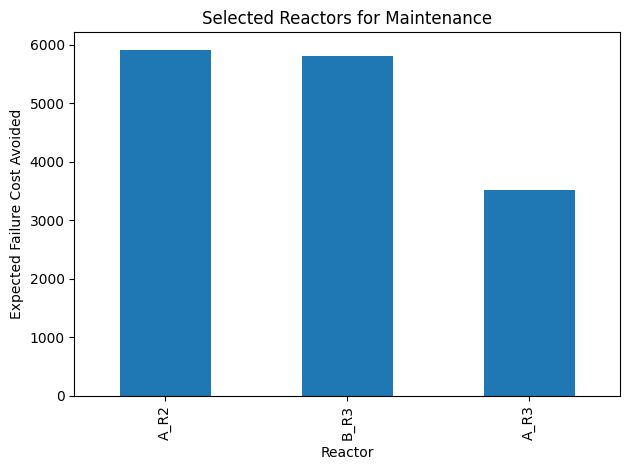

In [22]:
selected = optimization_results[
    optimization_results["selected_for_maintenance"] == 1
]

selected.plot(
    x="reactor_id",
    y="expected_failure_cost",
    kind="bar",
    legend=False
)

plt.title("Selected Reactors for Maintenance")
plt.xlabel("Reactor")
plt.ylabel("Expected Failure Cost Avoided")
plt.tight_layout()
plt.savefig("../outputs/figures/selected_reactors_for_maintenance.png")
plt.show()

The maintenance optimization problem selects reactors for preventive maintenance based on predicted failure risk and expected efficiency loss. The decision variable is binary: a reactor is either selected for maintenance or not. The objective is to maximize the expected failure cost avoided, subject to technician-hour, downtime, and budget constraints.

This converts the machine-learning output into a prescriptive decision-support tool. Instead of only predicting which reactors are risky, the model recommends which reactors should be maintained first when resources are limited.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

pred = pd.read_csv("../outputs/results/failure_risk_predictions.csv")

pred["valid_time_to_fault"] = pred["time_to_fault_min"].where(
    pred["time_to_fault_min"] > 0
)

reactor_risk = pred.groupby("reactor_id").agg(
    avg_predicted_failure_risk=("predicted_failure_risk", "mean"),
    max_predicted_failure_risk=("predicted_failure_risk", "max"),
    predicted_failure_count=("predicted_failure_label", "sum"),
    actual_failure_rate=("failure_risk", "mean"),
    avg_efficiency_loss=("efficiency_loss_pct", "mean"),
    min_time_to_fault=("valid_time_to_fault", "min"),
    avg_time_to_fault=("valid_time_to_fault", "mean")
).reset_index()

#maintenance planning parameters
reactor_risk["maintenance_hours"] = 3
reactor_risk["downtime_hours"] = 2
reactor_risk["maintenance_cost"] = 1000

#urgency score
reactor_risk["urgency_score"] = 1 / (reactor_risk["min_time_to_fault"] + 1)
reactor_risk["urgency_score"] = reactor_risk["urgency_score"].fillna(0)

#normalizing risk, efficiency loss, and urgency
score_cols = [
    "avg_predicted_failure_risk",
    "avg_efficiency_loss",
    "urgency_score"
]

scaler = MinMaxScaler()
scaled = scaler.fit_transform(reactor_risk[score_cols])

reactor_risk["risk_score_norm"] = scaled[:, 0]
reactor_risk["efficiency_loss_norm"] = scaled[:, 1]
reactor_risk["urgency_score_norm"] = scaled[:, 2]

#final maintenance benefit score
reactor_risk["maintenance_benefit"] = (
    0.5 * reactor_risk["risk_score_norm"]
    + 0.3 * reactor_risk["efficiency_loss_norm"]
    + 0.2 * reactor_risk["urgency_score_norm"]
)

reactor_risk.sort_values("maintenance_benefit", ascending=False)

,reactor_id,avg_predicted_failure_risk,max_predicted_failure_risk,predicted_failure_count,actual_failure_rate,avg_efficiency_loss,min_time_to_fault,avg_time_to_fault,maintenance_hours,downtime_hours,maintenance_cost,urgency_score,risk_score_norm,efficiency_loss_norm,urgency_score_norm,maintenance_benefit
5,B_R3,0.116935,0.986867,1363,0.055710,0.929208,0.029029,328.771599,4,2,1000,0.971790,1.000000,0.883208,1.000000,0.964962
1,A_R2,0.065886,0.782827,1460,0.070139,1.052083,0.129741,588.307452,4,2,1000,0.885158,0.460731,1.000000,0.910853,0.712536
2,A_R3,0.036498,0.582024,774,0.042052,0.631173,1.000000,916.911186,4,2,1000,0.500000,0.150277,0.599927,0.514514,0.358020
3,B_R1,0.028982,0.784873,162,0.011883,0.178241,1.000000,267.470196,4,2,1000,0.500000,0.070880,0.169417,0.514514,0.189168
4,B_R2,0.022272,0.476758,10,0.013619,0.203799,1.000000,297.740539,4,2,1000,0.500000,0.000000,0.193710,0.514514,0.161016
0,A_R1,0.030990,0.146220,0,0.000000,0.000000,NaN,NaN,4,2,1000,0.000000,0.092099,0.000000,0.000000,0.046049


In [32]:
from pulp import LpProblem, LpVariable, LpMaximize, lpSum, LpBinary, LpStatus, value

# Sets
R = reactor_risk["reactor_id"].tolist()

# Parameters
b = dict(zip(reactor_risk["reactor_id"], reactor_risk["maintenance_benefit"]))
h = dict(zip(reactor_risk["reactor_id"], reactor_risk["maintenance_hours"]))
d = dict(zip(reactor_risk["reactor_id"], reactor_risk["downtime_hours"]))
c = dict(zip(reactor_risk["reactor_id"], reactor_risk["maintenance_cost"]))

H = 12
D = 6
B = 4000

# Model
model = LpProblem("Maintenance_Optimization_Improved", LpMaximize)

# Decision variables
x = LpVariable.dicts("x", R, cat=LpBinary)

# Objective
model += lpSum(b[i] * x[i] for i in R), "Total_Maintenance_Benefit"

# Constraints
model += lpSum(h[i] * x[i] for i in R) <= H, "Technician_Hours"
model += lpSum(d[i] * x[i] for i in R) <= D, "Downtime_Limit"
model += lpSum(c[i] * x[i] for i in R) <= B, "Budget_Limit"

# Solve
model.solve()

print("Status:", LpStatus[model.status])
print("Objective value:", value(model.objective))

for i in R:
    if value(x[i]) > 0.5:
        print(f"{i} selected for maintenance")

Status: Optimal
Objective value: 2.0355183471941993
A_R2 selected for maintenance
A_R3 selected for maintenance
B_R3 selected for maintenance


In [33]:
optimization_results = reactor_risk.copy()

optimization_results["selected_for_maintenance"] = optimization_results["reactor_id"].apply(
    lambda r: int(x[r].value())
)

optimization_results = optimization_results.sort_values(
    ["selected_for_maintenance", "maintenance_benefit"],
    ascending=[False, False]
)

optimization_results[
    [
        "reactor_id",
        "avg_predicted_failure_risk",
        "avg_efficiency_loss",
        "min_time_to_fault",
        "maintenance_benefit",
        "maintenance_hours",
        "downtime_hours",
        "maintenance_cost",
        "selected_for_maintenance"
    ]
]

,reactor_id,avg_predicted_failure_risk,avg_efficiency_loss,min_time_to_fault,maintenance_benefit,maintenance_hours,downtime_hours,maintenance_cost,selected_for_maintenance
5,B_R3,0.116935,0.929208,0.029029,0.964962,4,2,1000,1
1,A_R2,0.065886,1.052083,0.129741,0.712536,4,2,1000,1
2,A_R3,0.036498,0.631173,1.000000,0.358020,4,2,1000,1
3,B_R1,0.028982,0.178241,1.000000,0.189168,4,2,1000,0
4,B_R2,0.022272,0.203799,1.000000,0.161016,4,2,1000,0
0,A_R1,0.030990,0.000000,NaN,0.046049,4,2,1000,0


################# IMPROVING OPTIMAZATION MODEL #################


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

pred = pd.read_csv("../outputs/results/failure_risk_predictions.csv")

# Treat zero time to fault as not valid for urgency calculation
pred["valid_time_to_fault"] = pred["time_to_fault_min"].where(
    pred["time_to_fault_min"] > 0
)

reactor_risk = pred.groupby("reactor_id").agg(
    avg_predicted_failure_risk=("predicted_failure_risk", "mean"),
    max_predicted_failure_risk=("predicted_failure_risk", "max"),
    predicted_failure_count=("predicted_failure_label", "sum"),
    actual_failure_rate=("failure_risk", "mean"),
    avg_efficiency_loss=("efficiency_loss_pct", "mean"),
    min_time_to_fault=("valid_time_to_fault", "min"),
    avg_time_to_fault=("valid_time_to_fault", "mean")
).reset_index()

reactor_risk

,reactor_id,avg_predicted_failure_risk,max_predicted_failure_risk,predicted_failure_count,actual_failure_rate,avg_efficiency_loss,min_time_to_fault,avg_time_to_fault
0,A_R1,0.030990,0.146220,0,0.000000,0.000000,NaN,NaN
1,A_R2,0.065886,0.782827,1460,0.070139,1.052083,0.129741,588.307452
2,A_R3,0.036498,0.582024,774,0.042052,0.631173,1.000000,916.911186
3,B_R1,0.028982,0.784873,162,0.011883,0.178241,1.000000,267.470196
4,B_R2,0.022272,0.476758,10,0.013619,0.203799,1.000000,297.740539
5,B_R3,0.116935,0.986867,1363,0.055710,0.929208,0.029029,328.771599


In [35]:
reactor_risk["maintenance_hours"] = 3
reactor_risk["downtime_hours"] = 2
reactor_risk["maintenance_cost"] = 1000

available_technician_hours = 12
allowed_downtime_hours = 6
available_budget = 4000

In [36]:
reactor_risk["urgency_score"] = 1 / (reactor_risk["min_time_to_fault"] + 1)
reactor_risk["urgency_score"] = reactor_risk["urgency_score"].fillna(0)

score_cols = [
    "avg_predicted_failure_risk",
    "avg_efficiency_loss",
    "urgency_score"
]

scaler = MinMaxScaler()
scaled = scaler.fit_transform(reactor_risk[score_cols])

reactor_risk["risk_score_norm"] = scaled[:, 0]
reactor_risk["efficiency_loss_norm"] = scaled[:, 1]
reactor_risk["urgency_score_norm"] = scaled[:, 2]

reactor_risk["maintenance_benefit"] = (
    0.5 * reactor_risk["risk_score_norm"]
    + 0.3 * reactor_risk["efficiency_loss_norm"]
    + 0.2 * reactor_risk["urgency_score_norm"]
)

reactor_risk = reactor_risk.sort_values(
    "maintenance_benefit",
    ascending=False
)

reactor_risk[
    [
        "reactor_id",
        "avg_predicted_failure_risk",
        "avg_efficiency_loss",
        "min_time_to_fault",
        "risk_score_norm",
        "efficiency_loss_norm",
        "urgency_score_norm",
        "maintenance_benefit"
    ]
]

,reactor_id,avg_predicted_failure_risk,avg_efficiency_loss,min_time_to_fault,risk_score_norm,efficiency_loss_norm,urgency_score_norm,maintenance_benefit
5,B_R3,0.116935,0.929208,0.029029,1.000000,0.883208,1.000000,0.964962
1,A_R2,0.065886,1.052083,0.129741,0.460731,1.000000,0.910853,0.712536
2,A_R3,0.036498,0.631173,1.000000,0.150277,0.599927,0.514514,0.358020
3,B_R1,0.028982,0.178241,1.000000,0.070880,0.169417,0.514514,0.189168
4,B_R2,0.022272,0.203799,1.000000,0.000000,0.193710,0.514514,0.161016
0,A_R1,0.030990,0.000000,NaN,0.092099,0.000000,0.000000,0.046049


The improved maintenance benefit score combines predicted failure risk, expected efficiency loss, and urgency. This prevents the optimizer from selecting reactors only because of high efficiency loss while ignoring short time-to-fault.

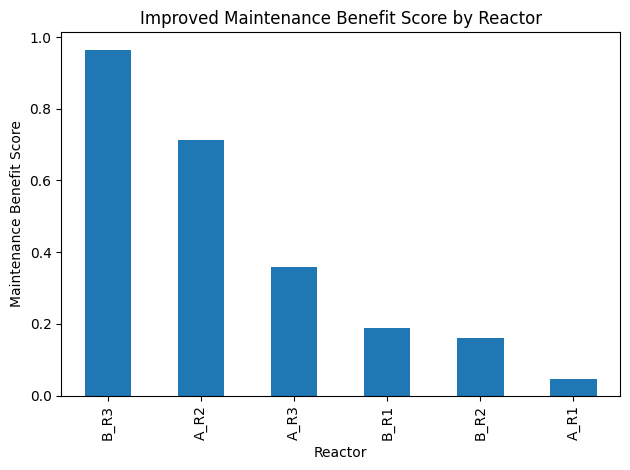

In [38]:
reactor_risk.plot(
    x="reactor_id",
    y="maintenance_benefit",
    kind="bar",
    legend=False
)

plt.title("Improved Maintenance Benefit Score by Reactor")
plt.xlabel("Reactor")
plt.ylabel("Maintenance Benefit Score")
plt.tight_layout()
plt.savefig("../outputs/figures/improved_model_maintenance_benefit_score.png")
plt.show()

In [39]:
from pulp import LpProblem, LpVariable, LpMaximize, lpSum, LpBinary, LpStatus, value

# Sets
reactors = reactor_risk["reactor_id"].tolist()

# Parameters
benefit = dict(zip(reactor_risk["reactor_id"], reactor_risk["maintenance_benefit"]))
hours = dict(zip(reactor_risk["reactor_id"], reactor_risk["maintenance_hours"]))
downtime = dict(zip(reactor_risk["reactor_id"], reactor_risk["downtime_hours"]))
cost = dict(zip(reactor_risk["reactor_id"], reactor_risk["maintenance_cost"]))

# Model
model = LpProblem("Improved_Maintenance_Optimization", LpMaximize)

# Decision variables
x = LpVariable.dicts("maintain", reactors, cat=LpBinary)

# Objective
model += lpSum(benefit[r] * x[r] for r in reactors)

# Constraints
model += lpSum(hours[r] * x[r] for r in reactors) <= available_technician_hours
model += lpSum(downtime[r] * x[r] for r in reactors) <= allowed_downtime_hours
model += lpSum(cost[r] * x[r] for r in reactors) <= available_budget

# Solve
model.solve()

print("Status:", LpStatus[model.status])
print("Objective value:", value(model.objective))

Status: Optimal
Objective value: 2.0355183471941993


In [40]:
optimization_results = reactor_risk.copy()

optimization_results["selected_for_maintenance"] = optimization_results["reactor_id"].apply(
    lambda r: int(x[r].value())
)

optimization_results = optimization_results.sort_values(
    ["selected_for_maintenance", "maintenance_benefit"],
    ascending=[False, False]
)

optimization_results

,reactor_id,avg_predicted_failure_risk,max_predicted_failure_risk,predicted_failure_count,actual_failure_rate,avg_efficiency_loss,min_time_to_fault,avg_time_to_fault,maintenance_hours,downtime_hours,maintenance_cost,urgency_score,risk_score_norm,efficiency_loss_norm,urgency_score_norm,maintenance_benefit,selected_for_maintenance
5,B_R3,0.116935,0.986867,1363,0.055710,0.929208,0.029029,328.771599,3,2,1000,0.971790,1.000000,0.883208,1.000000,0.964962,1
1,A_R2,0.065886,0.782827,1460,0.070139,1.052083,0.129741,588.307452,3,2,1000,0.885158,0.460731,1.000000,0.910853,0.712536,1
2,A_R3,0.036498,0.582024,774,0.042052,0.631173,1.000000,916.911186,3,2,1000,0.500000,0.150277,0.599927,0.514514,0.358020,1
3,B_R1,0.028982,0.784873,162,0.011883,0.178241,1.000000,267.470196,3,2,1000,0.500000,0.070880,0.169417,0.514514,0.189168,0
4,B_R2,0.022272,0.476758,10,0.013619,0.203799,1.000000,297.740539,3,2,1000,0.500000,0.000000,0.193710,0.514514,0.161016,0
0,A_R1,0.030990,0.146220,0,0.000000,0.000000,NaN,NaN,3,2,1000,0.000000,0.092099,0.000000,0.000000,0.046049,0


In [41]:
optimization_results.to_csv(
    "../outputs/results/improved_maintenance_optimization_results.csv",
    index=False
)

In [ ]:
#load first model results
first_model_results = pd.read_csv(
    "../outputs/results/maintenance_optimization_results.csv"
)

#localsoad second model results
second_model_results = pd.read_csv(
    "../outputs/results/improved_maintenance_optimization_results.csv"
)

#selected reactors from first model
first_model_selected = first_model_results[
    first_model_results["selected_for_maintenance"] == 1
]["reactor_id"].tolist()

#selected reactors from second model
second_model_selected = second_model_results[
    second_model_results["selected_for_maintenance"] == 1
]["reactor_id"].tolist()

print("First model selected reactors:", first_model_selected)
print("Second model selected reactors:", second_model_selected)

First model selected reactors: ['A_R2', 'B_R3', 'A_R3']
Second model selected reactors: ['B_R3', 'A_R2', 'A_R3']


The first and second optimization models selected the same three reactors: **A_R2, B_R3, and A_R3**. This indicates that these reactors consistently provide the highest maintenance value under the available technician-hour, downtime, and budget constraints.

The selection order changed in the improved model because the second objective uses a normalized maintenance-benefit score that combines predicted failure risk, efficiency loss, and urgency. As a result, **B_R3** is prioritized slightly higher than **A_R2**.

In [46]:
comparison = pd.DataFrame({
    "reactor_id": optimization_results["reactor_id"],
    "selected_first_model": optimization_results["reactor_id"].isin(first_model_selected).astype(int),
    "selected_second_model": optimization_results["reactor_id"].isin(second_model_selected).astype(int),
    "maintenance_benefit_second_model": optimization_results["maintenance_benefit"]
})

comparison

,reactor_id,selected_first_model,selected_second_model,maintenance_benefit_second_model
5,B_R3,1,1,0.964962
1,A_R2,1,1,0.712536
2,A_R3,1,1,0.358020
3,B_R1,0,0,0.189168
4,B_R2,0,0,0.161016
0,A_R1,0,0,0.046049


The comparison shows that both optimization models selected the same three reactors: **B_R3, A_R2, and A_R3**. This means these reactors remain the strongest maintenance candidates even after improving the objective function.

In the second model, **B_R3** has the highest maintenance benefit score (**0.965**), so it becomes the top priority. **A_R2** and **A_R3** are also selected because their benefit scores are higher than the non-selected reactors, while **B_R1, B_R2, and A_R1** remain below the selection threshold under the available technician-hour, downtime, and budget constraints.

In [47]:
comparison.to_csv(
    "../outputs/results/1model_vs_2model_comparison.csv",
    index=False
)

First model a basic expected-cost objective, while in the second model introduced a normalized maintenance benefit score. The improved model considers predicted risk, efficiency loss, and urgency simultaneously, making the maintenance recommendation more interpretable and better aligned with preventive maintenance logic.

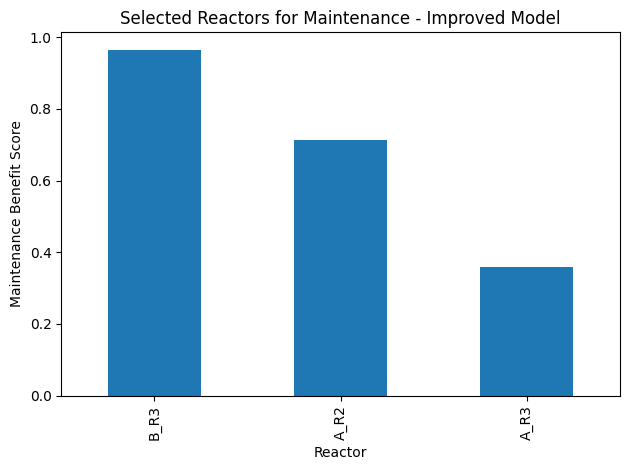

In [48]:
#Plot selected reactors
selected = optimization_results[
    optimization_results["selected_for_maintenance"] == 1
]

selected.plot(
    x="reactor_id",
    y="maintenance_benefit",
    kind="bar",
    legend=False
)

plt.title("Selected Reactors for Maintenance - Improved Model")
plt.xlabel("Reactor")
plt.ylabel("Maintenance Benefit Score")
plt.tight_layout()
plt.savefig("../outputs/figures/selected_reactors_improved_model.png")
plt.show()

The improved optimization model selects reactors for maintenance using a normalized maintenance benefit score. This score combines predicted failure risk, expected efficiency loss, and urgency based on minimum valid time-to-fault. The optimization model then maximizes total maintenance benefit while respecting technician-hour, downtime, and budget constraints.

Compared with the first model, this version is more suitable for preventive maintenance because it does not rely only on expected cost. It also accounts for how soon a fault may occur.

## Maintenance Optimization Problem

The objective of the optimization model is to select which reactors should receive preventive maintenance when resources are limited.

The model uses predicted failure risk from the machine learning model and combines it with efficiency loss and urgency to calculate a maintenance benefit score.

The optimization model then chooses the set of reactors that maximizes total maintenance benefit while respecting technician-hour, downtime, and budget constraints.

x[i] = 1 if reactor i is selected for preventive maintenance

x[i] = 0 otherwise

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pred = pd.read_csv("../outputs/results/failure_risk_predictions.csv")

pred["valid_time_to_fault"] = pred["time_to_fault_min"].where(
    pred["time_to_fault_min"] > 0
)

reactor_input = pred.groupby("reactor_id").agg(
    avg_predicted_failure_risk=("predicted_failure_risk", "mean"),
    max_predicted_failure_risk=("predicted_failure_risk", "max"),
    predicted_failure_count=("predicted_failure_label", "sum"),
    actual_failure_rate=("failure_risk", "mean"),
    avg_efficiency_loss=("efficiency_loss_pct", "mean"),
    min_time_to_fault=("valid_time_to_fault", "min"),
    avg_time_to_fault=("valid_time_to_fault", "mean"),
).reset_index()

reactor_input

,reactor_id,avg_predicted_failure_risk,max_predicted_failure_risk,predicted_failure_count,actual_failure_rate,avg_efficiency_loss,min_time_to_fault,avg_time_to_fault
0,A_R1,0.027764,0.149869,0,0.000000,0.000000,NaN,NaN
1,A_R2,0.065113,0.724842,1469,0.070139,1.052083,0.129741,588.307452
2,A_R3,0.037150,0.591525,772,0.042052,0.631173,1.000000,916.911186
3,B_R1,0.027000,0.799117,167,0.011883,0.178241,1.000000,267.470196
4,B_R2,0.021743,0.491916,21,0.013619,0.203799,1.000000,297.740539
5,B_R3,0.111759,0.983418,1363,0.055710,0.929208,0.029029,328.771599


In [51]:
reactor_input.to_csv(
    "../outputs/results/reactor_decision_input.csv",
    index=False
)

In [52]:
reactor_input["maintenance_hours"] = 3
reactor_input["downtime_hours"] = 2
reactor_input["maintenance_cost"] = 1000

available_technician_hours = 12
allowed_downtime_hours = 6
available_budget = 4000

Because the dataset does not include real maintenance cost, labor capacity, or downtime cost data, assumed planning parameters are used. These assumptions are not intended to represent a specific chemical plant. They are used to demonstrate how predicted failure risk can be converted into an optimization-based maintenance decision.

maintenance_benefit =
0.50 × normalized predicted failure risk + 0.30 × normalized efficiency loss + 0.20 × normalized urgency

In [53]:
from sklearn.preprocessing import MinMaxScaler

reactor_input["urgency_score"] = 1 / (reactor_input["min_time_to_fault"] + 1)
reactor_input["urgency_score"] = reactor_input["urgency_score"].fillna(0)

score_cols = [
    "avg_predicted_failure_risk",
    "avg_efficiency_loss",
    "urgency_score",
]

scaler = MinMaxScaler()
scaled = scaler.fit_transform(reactor_input[score_cols])

reactor_input["risk_score_norm"] = scaled[:, 0]
reactor_input["efficiency_loss_norm"] = scaled[:, 1]
reactor_input["urgency_score_norm"] = scaled[:, 2]

reactor_input["maintenance_benefit"] = (
    0.50 * reactor_input["risk_score_norm"]
    + 0.30 * reactor_input["efficiency_loss_norm"]
    + 0.20 * reactor_input["urgency_score_norm"]
)

reactor_input = reactor_input.sort_values(
    "maintenance_benefit",
    ascending=False
)

reactor_input

,reactor_id,avg_predicted_failure_risk,max_predicted_failure_risk,predicted_failure_count,actual_failure_rate,avg_efficiency_loss,min_time_to_fault,avg_time_to_fault,maintenance_hours,downtime_hours,maintenance_cost,urgency_score,risk_score_norm,efficiency_loss_norm,urgency_score_norm,maintenance_benefit
5,B_R3,0.111759,0.983418,1363,0.055710,0.929208,0.029029,328.771599,3,2,1000,0.971790,1.000000,0.883208,1.000000,0.964962
1,A_R2,0.065113,0.724842,1469,0.070139,1.052083,0.129741,588.307452,3,2,1000,0.885158,0.481801,1.000000,0.910853,0.723071
2,A_R3,0.037150,0.591525,772,0.042052,0.631173,1.000000,916.911186,3,2,1000,0.500000,0.171157,0.599927,0.514514,0.368460
3,B_R1,0.027000,0.799117,167,0.011883,0.178241,1.000000,267.470196,3,2,1000,0.500000,0.058394,0.169417,0.514514,0.182925
4,B_R2,0.021743,0.491916,21,0.013619,0.203799,1.000000,297.740539,3,2,1000,0.500000,0.000000,0.193710,0.514514,0.161016
0,A_R1,0.027764,0.149869,0,0.000000,0.000000,NaN,NaN,3,2,1000,0.000000,0.066886,0.000000,0.000000,0.033443


The maintenance benefit score is a weighted score used to rank reactors for preventive maintenance. Predicted failure risk receives the highest weight because the main goal is to prevent faults. Efficiency loss is included to reflect production impact. Urgency is included so reactors closer to a possible fault receive higher priority.

## Optimization Formulation

Let:

- \(i\) represent each reactor
- \(x_i\) be a binary decision variable
- \(b_i\) be the maintenance benefit score of reactor \(i\)
- \(h_i\) be required maintenance hours
- \(d_i\) be downtime hours
- \(c_i\) be maintenance cost

Objective:

Maximize total maintenance benefit:

\[
\max \sum_i b_i x_i
\]

Subject to:

\[
\sum_i h_i x_i \leq H
\]

\[
\sum_i d_i x_i \leq D
\]

\[
\sum_i c_i x_i \leq C
\]

\[
x_i \in \{0,1\}
\]

Where:

- \(H\) is available technician hours
- \(D\) is allowed downtime
- \(C\) is available maintenance budget

In [54]:
from pulp import (
    LpProblem,
    LpVariable,
    LpMaximize,
    lpSum,
    LpBinary,
    LpStatus,
    value,
)

reactors = reactor_input["reactor_id"].tolist()

model = LpProblem(
    "Preventive_Maintenance_Optimization",
    LpMaximize
)

x = {
    r: LpVariable(f"maintain_{r}", cat=LpBinary)
    for r in reactors
}

model += lpSum(
    reactor_input.loc[
        reactor_input["reactor_id"] == r,
        "maintenance_benefit"
    ].values[0] * x[r]
    for r in reactors
)

model += lpSum(
    reactor_input.loc[
        reactor_input["reactor_id"] == r,
        "maintenance_hours"
    ].values[0] * x[r]
    for r in reactors
) <= available_technician_hours

model += lpSum(
    reactor_input.loc[
        reactor_input["reactor_id"] == r,
        "downtime_hours"
    ].values[0] * x[r]
    for r in reactors
) <= allowed_downtime_hours

model += lpSum(
    reactor_input.loc[
        reactor_input["reactor_id"] == r,
        "maintenance_cost"
    ].values[0] * x[r]
    for r in reactors
) <= available_budget

model.solve()

print("Status:", LpStatus[model.status])
print("Objective value:", value(model.objective))

Status: Optimal
Objective value: 2.056493527480121


In [55]:
optimization_results = reactor_input.copy()

optimization_results["selected_for_maintenance"] = optimization_results["reactor_id"].apply(
    lambda r: int(x[r].value())
)

optimization_results = optimization_results.sort_values(
    ["selected_for_maintenance", "maintenance_benefit"],
    ascending=[False, False]
)

optimization_results[
    [
        "reactor_id",
        "avg_predicted_failure_risk",
        "avg_efficiency_loss",
        "min_time_to_fault",
        "maintenance_benefit",
        "maintenance_hours",
        "downtime_hours",
        "maintenance_cost",
        "selected_for_maintenance",
    ]
]

,reactor_id,avg_predicted_failure_risk,avg_efficiency_loss,min_time_to_fault,maintenance_benefit,maintenance_hours,downtime_hours,maintenance_cost,selected_for_maintenance
5,B_R3,0.111759,0.929208,0.029029,0.964962,3,2,1000,1
1,A_R2,0.065113,1.052083,0.129741,0.723071,3,2,1000,1
2,A_R3,0.037150,0.631173,1.000000,0.368460,3,2,1000,1
3,B_R1,0.027000,0.178241,1.000000,0.182925,3,2,1000,0
4,B_R2,0.021743,0.203799,1.000000,0.161016,3,2,1000,0
0,A_R1,0.027764,0.000000,NaN,0.033443,3,2,1000,0


In [56]:
optimization_results.to_csv(
    "../outputs/results/final_optimization_results.csv",
    index=False
)

In [57]:
selected = optimization_results[
    optimization_results["selected_for_maintenance"] == 1
]

resource_summary = {
    "selected_reactors": selected["reactor_id"].tolist(),
    "number_selected": len(selected),
    "total_maintenance_hours": selected["maintenance_hours"].sum(),
    "total_downtime_hours": selected["downtime_hours"].sum(),
    "total_maintenance_cost": selected["maintenance_cost"].sum(),
    "available_technician_hours": available_technician_hours,
    "allowed_downtime_hours": allowed_downtime_hours,
    "available_budget": available_budget,
    "total_maintenance_benefit": selected["maintenance_benefit"].sum(),
}

resource_summary_df = pd.DataFrame([resource_summary])
resource_summary_df

,selected_reactors,number_selected,total_maintenance_hours,total_downtime_hours,total_maintenance_cost,available_technician_hours,allowed_downtime_hours,available_budget,total_maintenance_benefit
0,"[B_R3, A_R2, A_R3]",3,9,6,3000,12,6,4000,2.056494


In [58]:
resource_summary_df.to_csv(
    "../outputs/results/optimization_resource_summary.csv",
    index=False
)

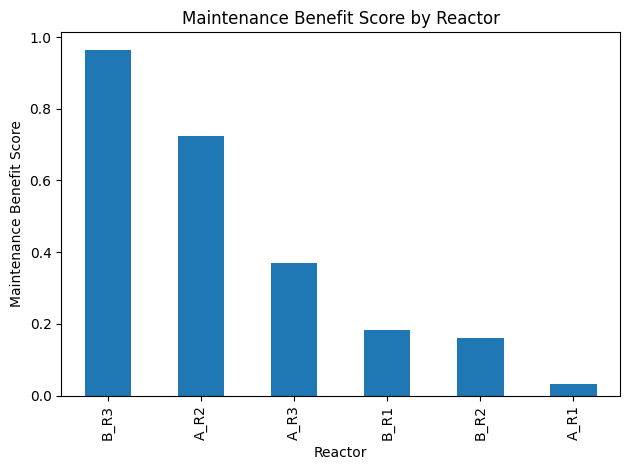

In [59]:
optimization_results.sort_values("maintenance_benefit", ascending=False).plot(
    x="reactor_id",
    y="maintenance_benefit",
    kind="bar",
    legend=False
)

plt.title("Maintenance Benefit Score by Reactor")
plt.xlabel("Reactor")
plt.ylabel("Maintenance Benefit Score")
plt.tight_layout()
plt.savefig("../outputs/figures/maintenance_benefit_score_by_reactor.png")
plt.show()

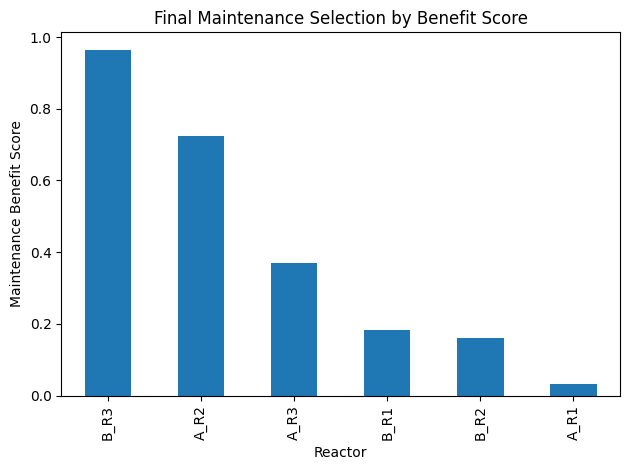

In [60]:
plot_df = optimization_results.copy()
plot_df["selection_status"] = plot_df["selected_for_maintenance"].map({
    1: "Selected",
    0: "Not Selected",
})

plot_df.plot(
    x="reactor_id",
    y="maintenance_benefit",
    kind="bar",
    legend=False
)

plt.title("Final Maintenance Selection by Benefit Score")
plt.xlabel("Reactor")
plt.ylabel("Maintenance Benefit Score")
plt.tight_layout()
plt.savefig("../outputs/figures/final_maintenance_selection.png")
plt.show()